# 3 · Ground-state energy and quantum natural gradient

A QBM can estimate the **ground-state energy** of a Hamiltonian $H$ by minimising
$\;L(\theta) = \mathrm{Tr}[H\,\rho(\theta)]$. As $\theta$ grows along the right
direction, $\rho(\theta)$ concentrates on the ground state.

The gradient is $\partial_j L = \mathrm{Tr}[H\,\partial_j\rho]$, where the state
derivative uses the eigenbasis divided-difference kernel (the same machinery as
the belief-propagation channel).

## Quantum natural gradient

Ordinary gradient descent ignores the geometry of state space. **Quantum natural
gradient** preconditions the step by a quantum-Fisher-information metric $g$:

$$\theta \leftarrow \theta - \eta\, (g + \lambda I)^{-1}\,\nabla L .$$

For Gibbs states the natural metric is **Kubo–Mori** (it is the Hessian of the
free energy). We compare GD, Adam and QNG below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm

n = 4
H = qbm.hamiltonians.tfim(n, J=1.0, g=1.5)
e0 = qbm.oracles.ground_energy(H)
print("exact ground energy:", round(e0, 6))

exact ground energy: -6.503892


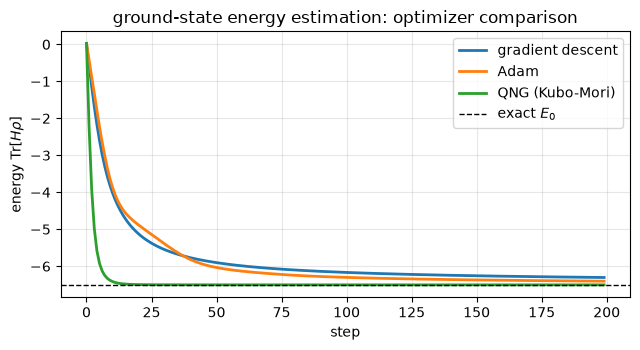

gradient descent   final energy = -6.30411   (error +2.00e-01)
Adam               final energy = -6.40373   (error +1.00e-01)
QNG (Kubo-Mori)    final energy = -6.50374   (error +1.47e-04)


In [2]:
def run(optimizer, steps=200):
    model = qbm.FullyVisibleQBM(n=n)
    model.theta = np.random.default_rng(0).normal(scale=0.05, size=model.n_params)
    hist = qbm.fit(model, qbm.losses.Energy(H), optimizer, steps=steps)
    return hist.loss

curves = {
    "gradient descent": run(qbm.optim.GradientDescent(lr=0.05)),
    "Adam":             run(qbm.optim.Adam(lr=0.05)),
    "QNG (Kubo-Mori)":  run(qbm.optim.NaturalGradient(metric="kubo_mori", lr=0.2, reg=1e-3)),
}

plt.figure(figsize=(6.5, 3.6))
for label, c in curves.items():
    plt.plot(c, lw=2, label=label)
plt.axhline(e0, ls="--", color="k", lw=1, label="exact $E_0$")
plt.xlabel("step"); plt.ylabel("energy $\\mathrm{Tr}[H\\rho]$")
plt.title("ground-state energy estimation: optimizer comparison")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for label, c in curves.items():
    print(f"{label:18s} final energy = {c[-1]:.5f}   (error {c[-1]-e0:+.2e})")

### The three quantum-Fisher-information metrics

`qbmkit` provides Fisher–Bures (SLD), Wigner–Yanase and Kubo–Mori metrics from a
single formula. They obey the Loewner orderings
$g_{\mathrm{FB}} \preceq g_{\mathrm{WY}} \preceq 2\,g_{\mathrm{FB}}$ and
$g_{\mathrm{KM}} \succeq g_{\mathrm{FB}}$, which we verify numerically.

g_FB <= g_WY : True
g_WY <= 2 g_FB: True
g_KM >= g_FB : True


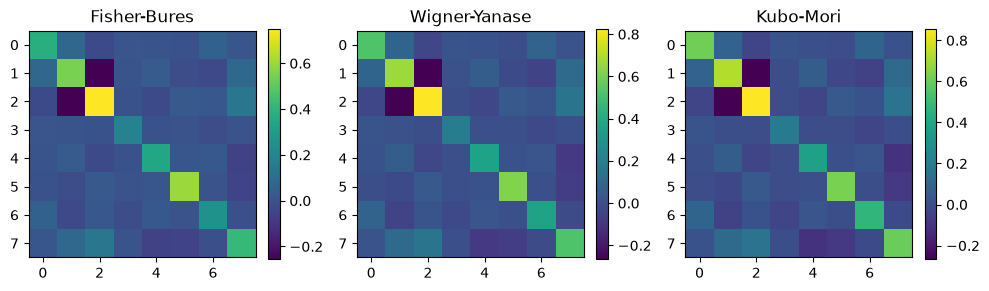

In [3]:
model = qbm.FullyVisibleQBM(n=3)
model.theta = np.random.default_rng(2).normal(scale=0.6, size=model.n_params)
st = model.state()
fb = st.metric("fisher_bures"); wy = st.metric("wigner_yanase"); km = st.metric("kubo_mori")

def psd(M):  # smallest eigenvalue >= 0 (up to round-off)
    return np.min(np.linalg.eigvalsh(M)) > -1e-9

print("g_FB <= g_WY :", psd(wy - fb))
print("g_WY <= 2 g_FB:", psd(2*fb - wy))
print("g_KM >= g_FB :", psd(km - fb))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, M) in zip(axes, [("Fisher-Bures", fb), ("Wigner-Yanase", wy), ("Kubo-Mori", km)]):
    im = ax.imshow(M, cmap="viridis"); ax.set_title(name)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### Recap

- Energy minimisation gives ground-state energies without barren-plateau-prone
  circuit ansätze.
- Quantum natural gradient (Kubo–Mori) converges much faster than plain GD.
- All three QFI metrics come from one kernel and respect the expected orderings.